# **Project:- Car Price Analysis**

## **Problem Statement**

The automotive industry generates large volumes of vehicle-related data containing information about car manufacturers, engine specifications, fuel types, pricing, fuel efficiency, transmission systems, and vehicle categories. However, businesses and automobile analysts often struggle to identify patterns related to pricing, fuel economy, brand popularity, and vehicle performance across different car segments.

## **Business Objectives**
This project aims to analyze the car dataset to uncover meaningful insights about vehicle specifications, pricing trends, fuel efficiency, transmission preferences, and brand positioning. Through data cleaning, preprocessing, exploratory data analysis (EDA), and Tableau dashboard visualization, the project will help stakeholders better understand the automobile market and support data-driven business decisions.

## **Importing Libraries**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("Cars_data.csv")

In [3]:
data

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


### **Basic Checks**

In [4]:
data.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
data.tail()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


In [6]:
data.sample(10)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
4608,Ford,F-250,1997,regular unleaded,220.0,8.0,MANUAL,rear wheel drive,3.0,NaN,Large,Extended Cab Pickup,17,12,5657,2787
8309,Land Rover,Range Rover,2015,flex-fuel (premium unleaded required/E85),340.0,6.0,AUTOMATIC,four wheel drive,4.0,"Flex Fuel,Luxury",Large,4dr SUV,23,17,258,83495
3387,Mazda,CX-7,2011,premium unleaded (recommended),244.0,4.0,AUTOMATIC,front wheel drive,4.0,Crossover,Midsize,4dr SUV,24,18,586,31640
3555,Cadillac,DeVille,2003,regular unleaded,275.0,8.0,AUTOMATIC,front wheel drive,4.0,Luxury,Large,Sedan,25,16,1624,49150
5877,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640,21595
4780,Ford,Focus,2015,flex-fuel (unleaded/E85),160.0,4.0,MANUAL,front wheel drive,4.0,Flex Fuel,Compact,Sedan,36,26,5657,18460
6371,Chrysler,Le Baron,1993,regular unleaded,141.0,6.0,AUTOMATIC,front wheel drive,2.0,NaN,Compact,Convertible,26,18,1013,2000
11072,Chevrolet,Uplander,2006,regular unleaded,201.0,6.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Passenger Minivan,23,16,1385,26250
3915,Lotus,Elise,2010,premium unleaded (required),189.0,4.0,MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Convertible,27,21,613,47250
10815,Mazda,Tribute,2010,regular unleaded,171.0,4.0,AUTOMATIC,front wheel drive,4.0,Crossover,Compact,4dr SUV,28,21,586,23590


In [7]:
data.shape

(11914, 16)

In [8]:
data.dtypes

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

In [9]:
data.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

## **Domain Analysis**
This dataset contains technical and market-related details of cars from various manufacturers.

**Key Business Features in Dataset**

| Feature           | Business Meaning                    |
| ----------------- | ----------------------------------- |
| Make              | Car manufacturer/company            |
| Model             | Specific vehicle model              |
| Year              | Manufacturing year                  |
| Engine Fuel Type  | Fuel used by vehicle                |
| Engine HP         | Horsepower indicating performance   |
| Engine Cylinders  | Engine capacity indicator           |
| Transmission Type | Manual/Automatic transmission       |
| Driven_Wheels     | Drivetrain type                     |
| Number of Doors   | Vehicle body configuration          |
| Market Category   | Vehicle market segment              |
| Vehicle Size      | Compact/Midsize/Large               |
| Vehicle Style     | SUV, Sedan, Coupe, etc.             |
| highway MPG       | Highway fuel efficiency             |
| city mpg          | City fuel efficiency                |
| Popularity        | Brand popularity score              |
| MSRP              | Manufacturer suggested retail price |


## **Descriptive Analysis**

In [10]:
data.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [11]:
data.describe(include='object')

,Make,Model,Engine Fuel Type,Transmission Type,Driven_Wheels,Market Category,Vehicle Size,Vehicle Style
count,11914,11914,11911,11914,11914,8172,11914,11914
unique,48,915,10,5,4,71,3,16
top,Chevrolet,Silverado 1500,regular unleaded,AUTOMATIC,front wheel drive,Crossover,Compact,Sedan
freq,1123,156,7172,8266,4787,1110,4764,3048


## **Data Cleaning**

In [12]:
data.duplicated().sum()

np.int64(715)

In [13]:
(data.duplicated().sum()/len(data))*100

np.float64(6.001342957864697)

In [14]:
data = data.drop_duplicates(ignore_index = True)

In [15]:
data.shape

(11199, 16)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11199 entries, 0 to 11198
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11199 non-null  object 
 1   Model              11199 non-null  object 
 2   Year               11199 non-null  int64  
 3   Engine Fuel Type   11196 non-null  object 
 4   Engine HP          11130 non-null  float64
 5   Engine Cylinders   11169 non-null  float64
 6   Transmission Type  11199 non-null  object 
 7   Driven_Wheels      11199 non-null  object 
 8   Number of Doors    11193 non-null  float64
 9   Market Category    7823 non-null   object 
 10  Vehicle Size       11199 non-null  object 
 11  Vehicle Style      11199 non-null  object 
 12  highway MPG        11199 non-null  int64  
 13  city mpg           11199 non-null  int64  
 14  Popularity         11199 non-null  int64  
 15  MSRP               11199 non-null  int64  
dtypes: float64(3), int64(5

In [17]:
data.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3376
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [18]:
(data['Market Category'].isnull().sum()/len(data))*100

np.float64(30.145548709706222)

In [19]:
data.loc[:,'Market Category'] = data['Market Category'].fillna('Unknown')

**Insights**

The Market Category column contained approximately **30% missing values**. Since the feature provides important business segmentation information for vehicle types and market positioning, the column was retained. Missing values were replaced with **`Unknown`** instead of using mode imputation to avoid introducing misleading category bias and to preserve data transparency during exploratory analysis and dashboard visualization.

In [20]:
data.loc[:,'Engine Fuel Type'] = data['Engine Fuel Type'].fillna(data['Engine Fuel Type'].mode()[0])

In [21]:
data.loc[:,'Engine HP'] = data['Engine HP'].fillna(data['Engine HP'].median())

In [22]:
data.loc[:,'Engine Cylinders'] = data['Engine Cylinders'].fillna(data['Engine Cylinders'].median())

In [23]:
data.loc[:,'Number of Doors'] = data['Number of Doors'].fillna(data['Number of Doors'].median())

**Insights**

Missing values were handled using median imputation for numerical variables and mode imputation for categorical variables. This approach helps preserve the dataset distribution while minimizing information loss, ensuring reliable exploratory analysis and dashboard visualization.

In [24]:
data.isnull().sum()

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64

In [25]:
data.shape

(11199, 16)

## **Exploratory Data Analysis**

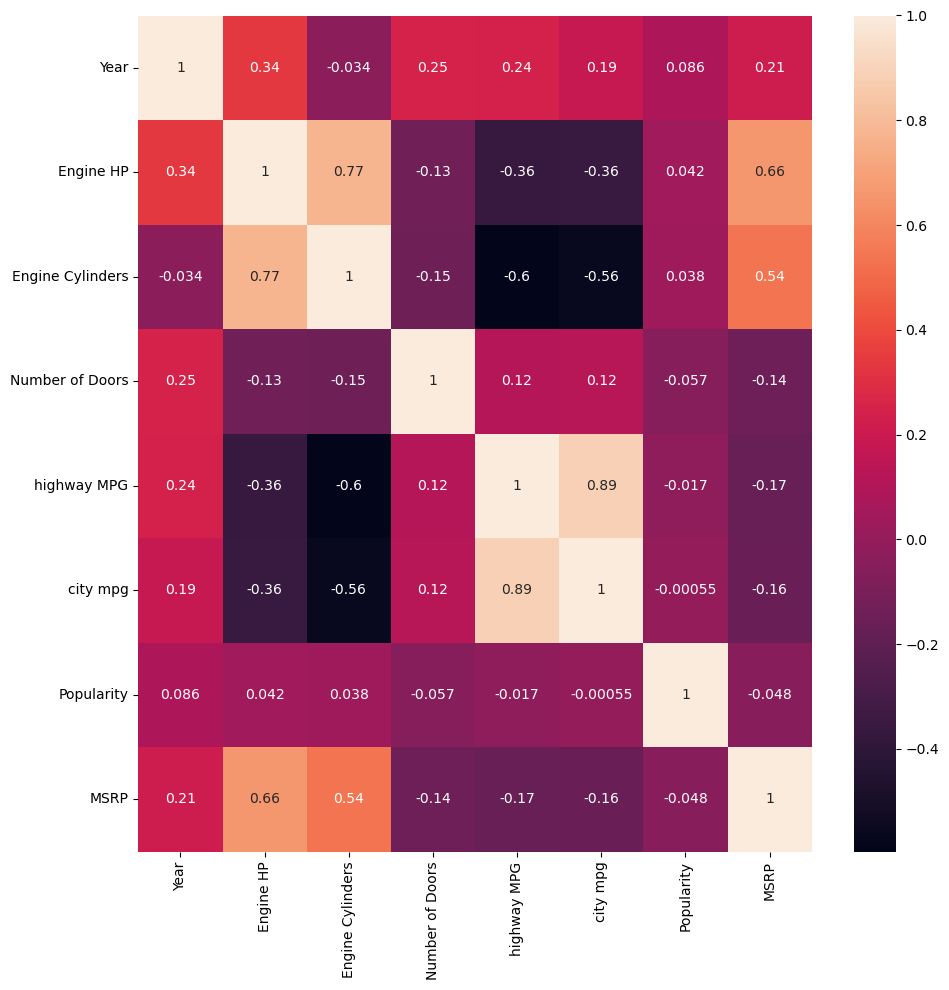

In [27]:
plt.figure(figsize = (10,10))
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.tight_layout()
plt.show()

### **Insights from Correlation Heatmap**
* **Performance vs. Price:** Engine HP and Engine Cylinders show a strong positive correlation with `MSRP`, confirming that performance metrics are primary drivers of vehicle pricing.
* **Fuel Efficiency Trade-off:** Both `highway MPG` and `city mpg` are negatively correlated with vehicle price and engine size, highlighting a clear divide between high-cost/high-performance vehicles and budget-friendly/fuel-efficient models.
* **Temporal Trend:** The positive correlation between `Year` and `MSRP` ($0.21$) reflects a consistent upward trend in vehicle prices over time.
* **Popularity vs. Luxury:** `Popularity` shows almost no linear relationship with `MSRP` ($0.086$), indicating that brand mainstream popularity does not inherently mean a higher price tag.

In [29]:
data.to_csv('Car_price_analysis.csv', index=False)